### Preliminary Operations

In [17]:
# importing basic libraries

import pandas as pd
import numpy as np

In [18]:
# warnings

import warnings
warnings.filterwarnings('ignore')

In [19]:
# importing training data

training_data=pd.read_csv('cleaned_training_data.csv')

In [20]:
# splitting our training data into independent and dependent variables

X=training_data.drop(columns=['Diagnosis'], axis=1)
y=training_data['Diagnosis']

In [21]:
# splitting our data into train and test splits

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=12)

### Basic Logistic Regression Model

In [22]:
# creating a basic logistic regression model

from sklearn.linear_model import LogisticRegression
logreg_basic=LogisticRegression()
logreg_basic.fit(X_train, y_train)

LogisticRegression()

In [23]:
# making predictions

y_pred=logreg_basic.predict(X_test)

In [24]:
# evaluating our model

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Basic Logistic Regression:\n")
print(f"Accuracy Score:{accuracy_score(y_test, y_pred)}\n\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}\n\nClassification Report:\n{classification_report(y_test, y_pred)}")

Basic Logistic Regression:

Accuracy Score:0.95

Confusion Matrix:
[[45  0]
 [ 4 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        45
           1       1.00      0.89      0.94        35

    accuracy                           0.95        80
   macro avg       0.96      0.94      0.95        80
weighted avg       0.95      0.95      0.95        80



### Hyper-Parameter Tuning our Model

In [25]:
# Implementing GridSearchCV on our Model

params={
    'penalty':['l1', 'l2', 'elasticnet', None],
    'solver':['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    'max_iter':[10,50,100,200,500,1000],
    'multi_class':['auto', 'ovr', 'multinomial']

}

from sklearn.model_selection import GridSearchCV, StratifiedKFold
cv=StratifiedKFold(n_splits=5)
grid=GridSearchCV( estimator=logreg_basic, param_grid=params, cv=cv, n_jobs=-1, scoring='accuracy')
grid.fit(X_train, y_train)

/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logis

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'max_iter': [10, 50, 100, 200, 500, 1000],
                         'multi_class': ['auto', 'ovr', 'multinomial'],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='accuracy')

In [26]:
grid.best_score_

np.float64(0.9811507936507937)

In [27]:
grid.best_params_

{'max_iter': 50,
 'multi_class': 'multinomial',
 'penalty': 'l2',
 'solver': 'lbfgs'}

### Creating and Exporting our Best Model

In [28]:
# training our best model

logreg_bestmodel=grid.best_estimator_
logreg_bestmodel.fit(X_train, y_train)

LogisticRegression(max_iter=50, multi_class='multinomial')

In [29]:
# evaluating our best model

y_pred_best=logreg_bestmodel.predict(X_test)

print("Logistic Regression (Best Estimator):\n")
print(f"Accuracy Score:{accuracy_score(y_test, y_pred)}\n\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_best)}\n\nClassification Report:\n{classification_report(y_test, y_pred_best)}")

Logistic Regression (Best Estimator):

Accuracy Score:0.95

Confusion Matrix:
[[45  0]
 [ 4 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        45
           1       1.00      0.89      0.94        35

    accuracy                           0.95        80
   macro avg       0.96      0.94      0.95        80
weighted avg       0.95      0.95      0.95        80



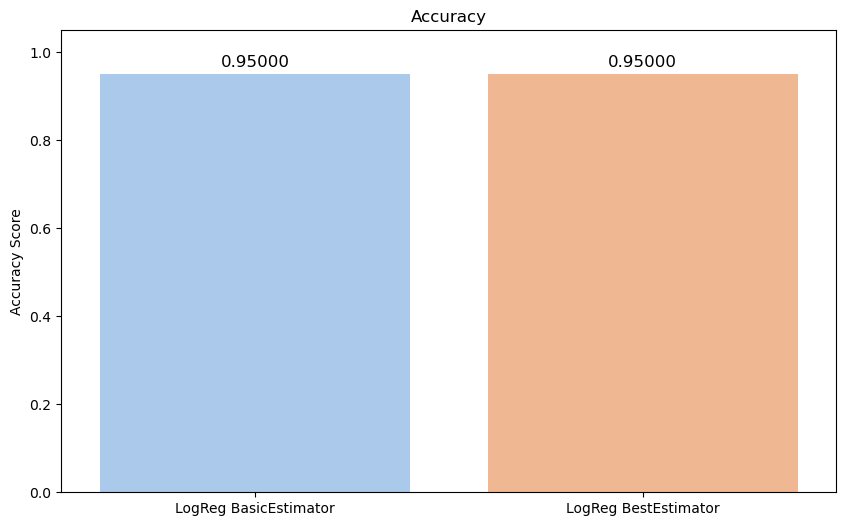

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.title("Accuracy")
plt.ylabel("Accuracy Score")
ax=sns.barplot(x=['LogReg BasicEstimator','LogReg BestEstimator'], y=(acc_scores:=[0.95,0.95]), palette='pastel')
plt.ylim(0,1.05)
for i, acc in enumerate(acc_scores):
    ax.text(i, acc + 0.01, f"{acc:.5f}", ha='center', va='bottom', fontsize=12)

In [14]:
# exporting our best model

import pickle
with open("logreg.pkl","wb") as f:
    pickle.dump(obj=logreg_bestmodel, file=f)
